In [ ]:
mport numpy as np
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/cleaned_data.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
# ML models (multi-feature)
X = df.drop(columns=['nat_demand'])
y = df['nat_demand']

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [ ]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf  = mean_absolute_error(y_test, pred_rf)

In [ ]:
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6)
xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae_xgb  = mean_absolute_error(y_test, pred_xgb)

In [ ]:
lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=6)
lgbm.fit(X_train, y_train)

pred_lgbm = lgbm.predict(X_test)

rmse_lgbm = np.sqrt(mean_squared_error(y_test, pred_lgbm))
mae_lgbm  = mean_absolute_error(y_test, pred_lgbm)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3934
[LightGBM] [Info] Number of data points in the train set: 38419, number of used features: 23
[LightGBM] [Info] Start training from score 1175.710578
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [ ]:
train_arima = y[:split]
test_arima  = y[split:]

model_arima = ARIMA(train_arima, order=(5,1,0))
model_fit = model_arima.fit()

pred_arima = model_fit.forecast(steps=len(test_arima))

rmse_arima = np.sqrt(mean_squared_error(test_arima, pred_arima))
mae_arima  = mean_absolute_error(test_arima, pred_arima)

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=0
)


In [ ]:
cat.fit(X_train, y_train)

pred_cat = cat.predict(X_test)

rmse_cat = np.sqrt(mean_squared_error(y_test, pred_cat))
mae_cat  = mean_absolute_error(y_test, pred_cat)

In [ ]:
!pip install statsmodels

In [ ]:
#lstm
from sklearn.preprocessing import MinMaxScaler

data = df['nat_demand'].values.reshape(-1,1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

import numpy as np

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 24

X_lstm, y_lstm = create_sequences(data_scaled, seq_length)

In [ ]:
split = int(len(X_lstm) * 0.8)

X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model_lstm.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, verbose=0)

In [ ]:
pred_lstm = model_lstm.predict(X_test_lstm)

In [ ]:
pred_lstm = scaler.inverse_transform(pred_lstm)
y_test_lstm_actual = scaler.inverse_transform(y_test_lstm)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_actual, pred_lstm))
mae_lstm  = mean_absolute_error(y_test_lstm_actual, pred_lstm)

In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost','LSTM'],
    'RMSE': [rmse_rf, rmse_xgb, rmse_lgbm, rmse_cat,  rmse_lstm],
    'MAE':  [mae_rf, mae_xgb, mae_lgbm, mae_cat,  mae_lstm]
})

print(results)


           Model       RMSE        MAE
0  Random Forest  27.853793  19.762836
1        XGBoost  25.210484  17.710097
2       LightGBM  24.681827  17.590609
3       CatBoost  25.047726  17.920614
4           LSTM  35.235262  25.836075


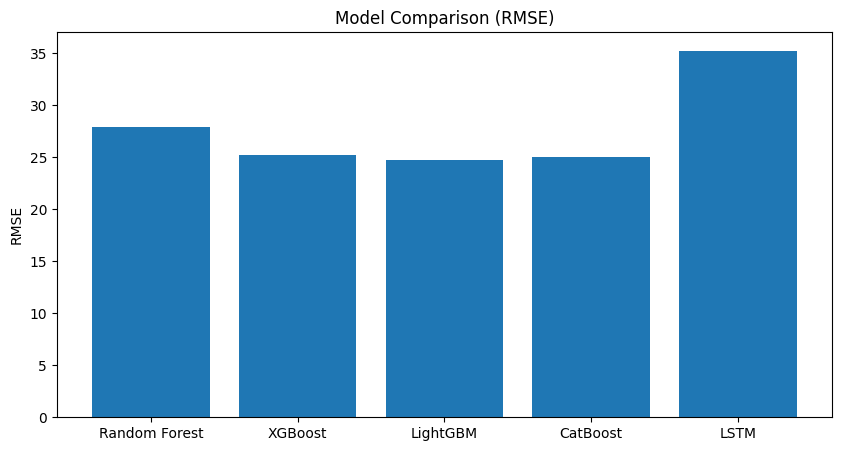

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results['Model'], results['RMSE'])
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()